# Importation des modules

In [1]:
import pandas as pd
import numpy as np
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
!pip install openpyxl
!pip install missingno
!pip install statsmodels

# Chargement des données
diviser les dépenses de santé par le PIB pour les avoir en %  
rajouter les données de dépenses de santé pour 1994 - 2004 en regardant sur les données de l'ocde  
rajouter la base mortalite  
faire le tri dans les pays de la bdd nb de médecins  


In [3]:
depenses_sante_vol = pd.read_excel(os.path.join("data", "Depenses_sante_en_volume_fr.xlsx"))
depenses_sante_PIB = pd.read_excel(os.path.join("data", "Depenses_Sante_PIB_OCDE_fr.xlsx"))
pib = pd.read_excel(os.path.join("data", "PIB_fr.xlsx"))
pib_par_habitant = pd.read_excel(os.path.join("data", "PIB_par_habitant_fr.xlsx"))
pop_tot = pd.read_excel(os.path.join("data", "Pop_tot_fr.xlsx"))
pop65 = pd.read_excel(os.path.join("data", "Pop+65ans_fr.xlsx"))
part_pop65 = pd.read_excel(os.path.join("data", "part_pop_plus_65_fr.xlsx"))
pop_par_age = pd.read_excel(os.path.join("data", "Population_par_age_tranches5ans_fr.xlsx"))
active_physicians = pd.read_excel(os.path.join("data", "active_physicians.xlsx"))
hospital_beds = pd.read_excel(os.path.join("data", "hospital_beds.xlsx"))
taux_deces_2ans = pd.read_excel('data/Taux_Deces_2ans.xlsx', index_col=None)
taux_deces_2ans = taux_deces_2ans.rename(columns={taux_deces_2ans.columns[0]: 'TIME'})

In [4]:
hospital_beds

,TIME,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Autriche,7.69,7.66,7.75,7.69,7.68,7.65,7.68,7.67,7.64,7.58,7.54,7.42,7.37,7.27,7.19,7.05,6.91,6.72,NaN
1,Belgique,6.02,5.98,5.93,5.89,5.83,5.75,5.69,5.64,5.61,5.63,5.69,5.64,5.55,5.52,5.47,5.44,5.41,5.35,5.30
2,Tchéquie,6.37,6.30,6.18,6.09,6.03,5.94,5.75,5.60,5.40,5.36,5.39,5.70,5.71,5.68,5.67,5.86,5.93,4.92,4.83
3,Danemark,3.86,3.79,3.69,3.57,3.49,3.50,3.13,NaN,3.07,2.69,2.53,2.60,2.61,2.61,2.59,2.59,2.51,NaN,NaN
4,Estonie,5.38,5.55,5.48,5.63,5.37,5.27,5.36,5.53,5.01,5.01,4.96,4.76,4.69,4.57,4.63,4.57,4.48,4.39,4.17
5,Finlande,7.05,6.99,6.73,6.57,6.25,5.85,5.52,5.30,4.87,4.53,4.35,3.97,3.28,3.21,3.30,2.83,2.76,NaN,NaN
6,France,7.22,7.11,7.06,6.90,6.66,6.43,6.36,6.34,6.27,6.20,6.13,6.06,5.98,5.89,5.83,5.72,NaN,NaN,NaN
7,Allemagne,6.26,6.13,5.57,6.10,6.11,6.20,6.24,6.22,6.20,6.17,6.11,6.06,6.01,5.96,6.00,5.87,5.81,5.78,NaN
8,Grèce,4.78,4.87,4.88,4.84,4.93,4.48,4.47,4.45,4.24,4.24,4.25,4.20,4.21,4.20,4.18,4.23,4.27,4.26,4.24
9,Hongrie,7.89,7.93,7.15,7.07,7.09,7.12,7.15,6.94,7.01,6.99,7.00,7.00,7.02,7.02,6.99,6.98,6.92,6.82,6.62


# Construction du Time-to-Death

In [5]:
def time_to_death(mortalite, pop) :
    # pour pop, à voir si on prend pop_tot, pop_65 ou une population plus âgée encore
    # ou faire une somme pondérée des mortalités pour les 65-70, 70-75, etc
    # fait par chatgpt, à revoir en fonction de la structure des données
    df = mortalite.merge(
        pop_tot,
        on=["country", "year", "age"],
        how="inner"
    )

    df["weighted_mortality"] = df["mortality_rate"] * df["population"]
    ttd = (
        df.groupby(["country", "year"])["weighted_mortality"]
          .sum()
          .reset_index(name="TTD")
    )
    return ttd

#pop = pop_65   # ou pop_80, ou pop_tot...
#ttd = time_to_death(mortalite, pop)

# Mise en forme du panel

In [6]:
def preparer_donnees(fichier, var) :   #var est un str indiquant le nom de la variable, comme "PIB" ou "depenses"
    df = fichier.copy()
    df = df.replace(':', np.nan)
    df = pd.melt(df, id_vars=['TIME'], var_name='Year', value_name=var)
    df = df.rename(columns={'TIME': 'Country'})
    df['Year'] = df['Year'].astype(int)  # S'assurer que l'année est un entier
    df = df.set_index(['Country', 'Year']).sort_index()
    return df

In [7]:
panel_depenses_sante_PIB = preparer_donnees(depenses_sante_PIB, "Depenses de sante en % du PIB")
panel_PIB_par_habitant = preparer_donnees(pib_par_habitant, "PIB par habitant")
panel = pd.merge(panel_depenses_sante_PIB, panel_PIB_par_habitant, on=['Country', 'Year'], how='outer')
panel_pop65 = preparer_donnees(part_pop65, "Part des +65 ans")
panel = pd.merge(panel, panel_pop65, on=['Country', 'Year'], how='outer')
panel_active_physicians = preparer_donnees(active_physicians, "Practiciens pour 1000 habitants")
panel = pd.merge(panel, panel_active_physicians, on=['Country', 'Year'], how='outer')
panel_hospital_beds = preparer_donnees(hospital_beds, "Lits d hôpitaux pour 1000 habitants")
panel = pd.merge(panel, panel_hospital_beds, on=['Country', 'Year'], how='outer')
panel_taux_deces_2ans = preparer_donnees(taux_deces_2ans, "Taux deces 2 ans")
panel = pd.merge(panel, panel_taux_deces_2ans, on=['Country', 'Year'], how='outer')
panel['Depenses t-1'] = panel.groupby(level='Country')['Depenses de sante en % du PIB'].shift(1)

# 3. Structuration en Panel (MultiIndex)
#panel = panel.set_index(['Country', 'Year']).sort_index()
panel.loc['Portugal']

,Depenses de sante en % du PIB,PIB par habitant,Part des +65 ans,Practiciens pour 1000 habitants,Lits d hôpitaux pour 1000 habitants,Taux deces 2 ans,Depenses t-1
Year,,,,,,,
1993,NaN,NaN,0.142398,NaN,NaN,NaN,NaN
1994,NaN,NaN,0.145039,NaN,NaN,NaN,NaN
1995,NaN,60.9,0.147758,NaN,NaN,NaN,NaN
1996,NaN,61.6,0.150645,NaN,NaN,NaN,NaN
1997,NaN,63.8,0.153210,NaN,NaN,NaN,NaN
1998,NaN,65.4,0.155996,NaN,NaN,NaN,NaN
1999,NaN,67.2,0.158368,NaN,NaN,NaN,NaN
2000,NaN,67.8,0.160296,NaN,NaN,NaN,NaN
2001,NaN,68.0,0.163408,NaN,NaN,NaN,NaN


In [8]:
annees_a_supprimer = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2024, 2025]
panel = panel.drop(annees_a_supprimer, level='Year')
panel = panel.drop("Suède", level='Country')
panel

Depenses de sante en % du PIB  PIB par habitant  \
Country   Year                                                    
Allemagne 2005                         10.107             129.3   
          2006                          9.962             128.1   
          2007                          9.835             127.2   
          2008                         10.032             126.3   
          2009                         10.970             127.9   
...                                       ...               ...   
Tchéquie  2019                          7.488              68.6   
          2020                          8.970              68.8   
          2021                          9.154              70.4   
          2022                          8.471              73.8   
          2023                          8.427              76.4   

                Part des +65 ans  Practiciens pour 1000 habitants  \
Country   Year                                                      
Allemagne 2005          0.186270                             3.40   
          2006          0.192509                             3.44   
          2007          0.198011                             3.49   
          2008          0.200914                             3.54   
          2009          0.204006                             3.62   
...                          ...                              ...   
Tchéquie  2019          0.195930                             4.07   
          2020          0.199331                             4.13   
          2021          0.205037                             4.26   
          2022          0.206254                             4.32   
          2023          0.203911                             4.86   

                Lits d hôpitaux pour 1000 habitants  Taux deces 2 ans  \
Country   Year                                                          
Allemagne 2005                                 6.26             2.002   
          2006                                 6.13             2.000   
          2007                                 5.57             2.031   
          2008                                 6.10             2.066   
          2009                                 6.11             2.089   
...                                             ...               ...   
Tchéquie  2019                                 5.67             2.269   
          2020                                 5.86             2.517   
          2021                                 5.93             2.478   
          2022                                 4.92             2.216   
          2023                                 4.83               NaN   

                Depenses t-1  
Country   Year                
Allemagne 2005         9.975  
          2006        10.107  
          2007         9.962  
          2008         9.835  
          2009        10.032  
...                      ...  
Tchéquie  2019         7.372  
          2020         7.488  
          2021         8.970  
          2022         9.154  
          2023         8.471  

[380 rows x 7 columns]

In [9]:
#panel_depenses_sante_PIB.to_excel("panel_depenses_sante_PIB.xlsx", index=False)
#panel_PIB_par_habitant.to_excel("panel_PIB_par_habitant.xlsx", index=False)
#panel_pop65.to_excel("panel_pop65.xlsx", index=False)
#panel = pd.merge(panel_depenses_sante_PIB, panel_PIB_par_habitant, on=['Country', 'Year'], how='outer')
panel.to_csv("panel.csv", index=False)

In [10]:
panel.loc[panel['Practiciens pour 1000 habitants'].isna()]

Depenses de sante en % du PIB  PIB par habitant  \
Country    Year                                                    
Allemagne  2023                         11.744             132.0   
Autriche   2023                         11.153             136.4   
Danemark   2022                          9.474             178.3   
           2023                          9.513             163.9   
Finlande   2022                          9.742             132.5   
           2023                         10.474             127.5   
France     2023                         11.503             107.7   
Irlande    2005                          7.642             185.2   
           2006                          7.516             185.7   
           2007                          7.808             181.5   
           2008                          9.126             164.0   
           2009                         10.523             154.2   
           2010                         10.521             146.2   
Italie     2023                          8.406              94.7   
Luxembourg 2018                          5.274             322.7   
           2019                          5.466             316.8   
           2020                          5.767             334.9   
           2021                          5.608             342.5   
           2022                          5.609             324.0   
           2023                          5.668             320.4   
Portugal   2023                         10.028              66.6   

                 Part des +65 ans  Practiciens pour 1000 habitants  \
Country    Year                                                      
Allemagne  2023          0.222456                              NaN   
Autriche   2023          0.195579                              NaN   
Danemark   2022          0.203496                              NaN   
           2023          0.204517                              NaN   
Finlande   2022          0.230530                              NaN   
           2023          0.232660                              NaN   
France     2023          0.211297                              NaN   
Irlande    2005          0.111046                              NaN   
           2006          0.109666                              NaN   
           2007          0.108029                              NaN   
           2008          0.107764                              NaN   
           2009          0.109440                              NaN   
           2010          0.112171                              NaN   
Italie     2023          0.240372                              NaN   
Luxembourg 2018          0.143201                              NaN   
           2019          0.143882                              NaN   
           2020          0.145002                              NaN   
           2021          0.146105                              NaN   
           2022          0.147505                              NaN   
           2023          0.148636                              NaN   
Portugal   2023          0.238756                              NaN   

                 Lits d hôpitaux pour 1000 habitants  Taux deces 2 ans  \
Country    Year                                                          
Allemagne  2023                                  NaN               NaN   
Autriche   2023                                  NaN             1.958   
Danemark   2022                                  NaN             2.006   
           2023                                  NaN               NaN   
Finlande   2022                                  NaN             2.245   
           2023                                  NaN               NaN   
France     2023                                  NaN               NaN   
Irlande    2005                                 5.52             1.380   
           2006                                 5.34             1.345   
           2007            

In [11]:
panel.loc[panel['Lits d hôpitaux pour 1000 habitants'].isna()]

Depenses de sante en % du PIB  PIB par habitant  \
Country    Year                                                    
Allemagne  2023                         11.744             132.0   
Autriche   2023                         11.153             136.4   
Danemark   2012                         10.517             175.1   
           2022                          9.474             178.3   
           2023                          9.513             163.9   
Finlande   2022                          9.742             132.5   
           2023                         10.474             127.5   
France     2021                         12.249             111.0   
           2022                         11.835             107.7   
           2023                         11.503             107.7   
Lettonie   2023                          7.278              54.8   
Luxembourg 2021                          5.608             342.5   
           2022                          5.609             324.0   
           2023                          5.668             320.4   
Portugal   2023                         10.028              66.6   

                 Part des +65 ans  Practiciens pour 1000 habitants  \
Country    Year                                                      
Allemagne  2023          0.222456                              NaN   
Autriche   2023          0.195579                              NaN   
Danemark   2012          0.173476                             3.84   
           2022          0.203496                              NaN   
           2023          0.204517                              NaN   
Finlande   2022          0.230530                              NaN   
           2023          0.232660                              NaN   
France     2021          0.206266                             3.18   
           2022          0.208694                             3.19   
           2023          0.211297                              NaN   
Lettonie   2023          0.209727                             3.36   
Luxembourg 2021          0.146105                              NaN   
           2022          0.147505                              NaN   
           2023          0.148636                              NaN   
Portugal   2023          0.238756                              NaN   

                 Lits d hôpitaux pour 1000 habitants  Taux deces 2 ans  \
Country    Year                                                          
Allemagne  2023                                  NaN               NaN   
Autriche   2023                                  NaN             1.958   
Danemark   2012                                  NaN             1.878   
           2022                                  NaN             2.006   
           2023                                  NaN               NaN   
Finlande   2022                                  NaN             2.245   
           2023                                  NaN               NaN   
France     2021                                  NaN             1.974   
           2022                                  NaN             1.931   
           2023                                  NaN               NaN   
Lettonie   2023                                  NaN               NaN   
Luxembourg 2021                                  NaN             1.408   
           2022                                  NaN             1.376   
           2023                                  NaN               NaN   
Portugal   2023                                  NaN             2.250   

                 Depenses t-1  
Country    Year                
Allemagne  2023        12.447  
Autriche   2023        11.225  
Danemark   2012        10.378  
           2022        10.656  
           2023         9.474  
Finlande   2022         9.910  
           2023         9.742  
France     2021        12.129  
           2022        12.249  
           2023        11.835  
Lettonie   2023         8.

## Visualisation des valeurs manquantes

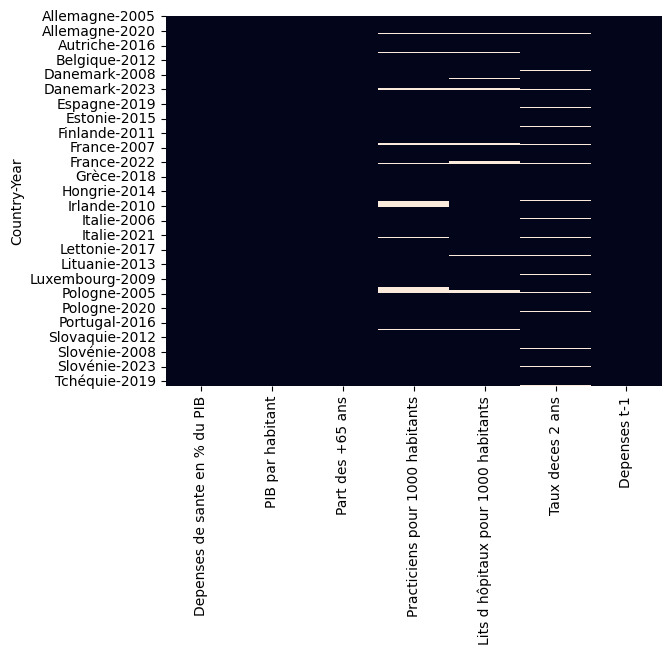

In [12]:
df = panel.copy()
sns.heatmap(df.isna(), cbar=False)
plt.show()

<Axes: >

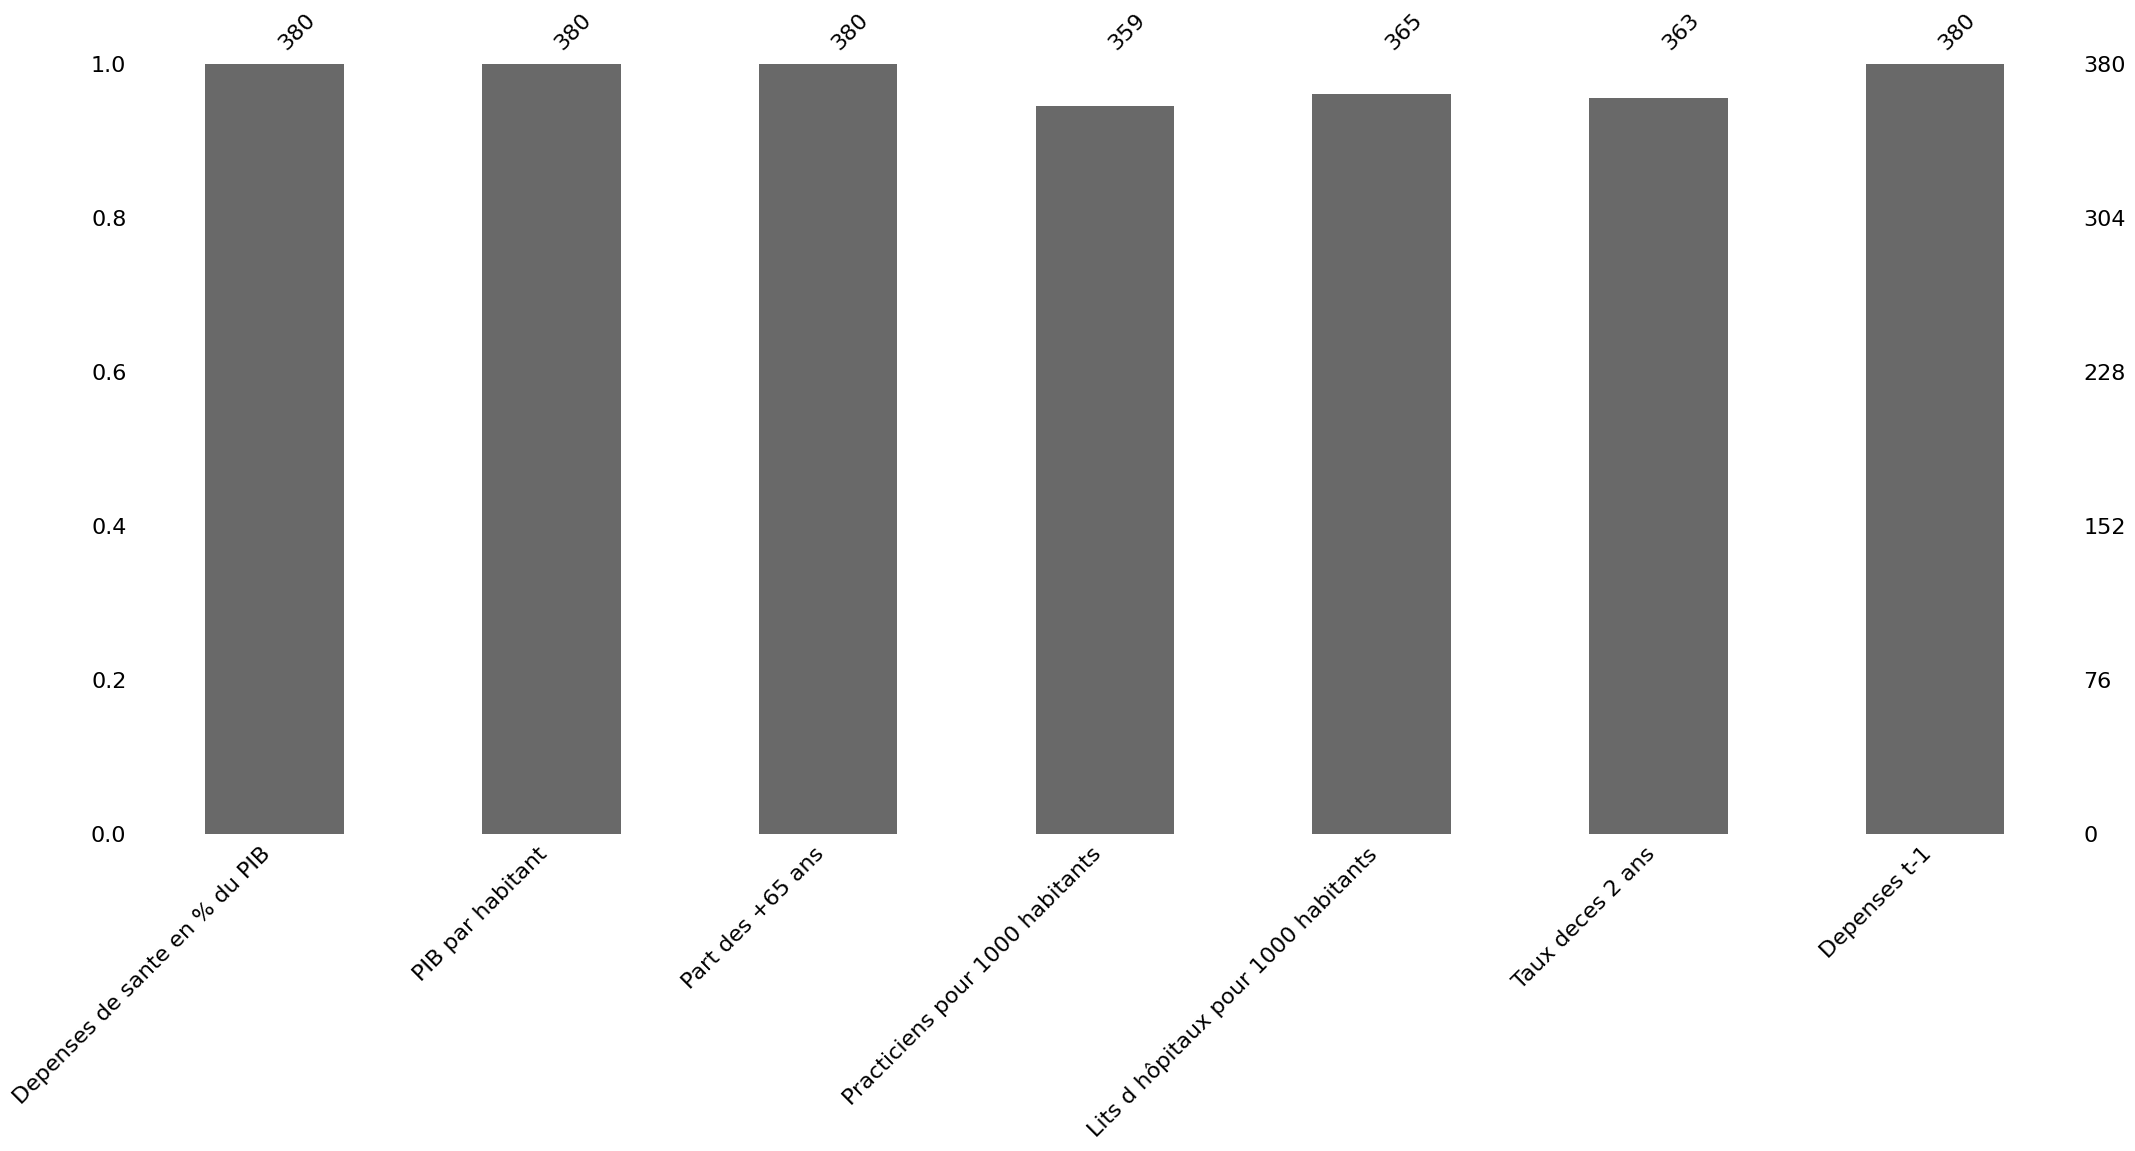

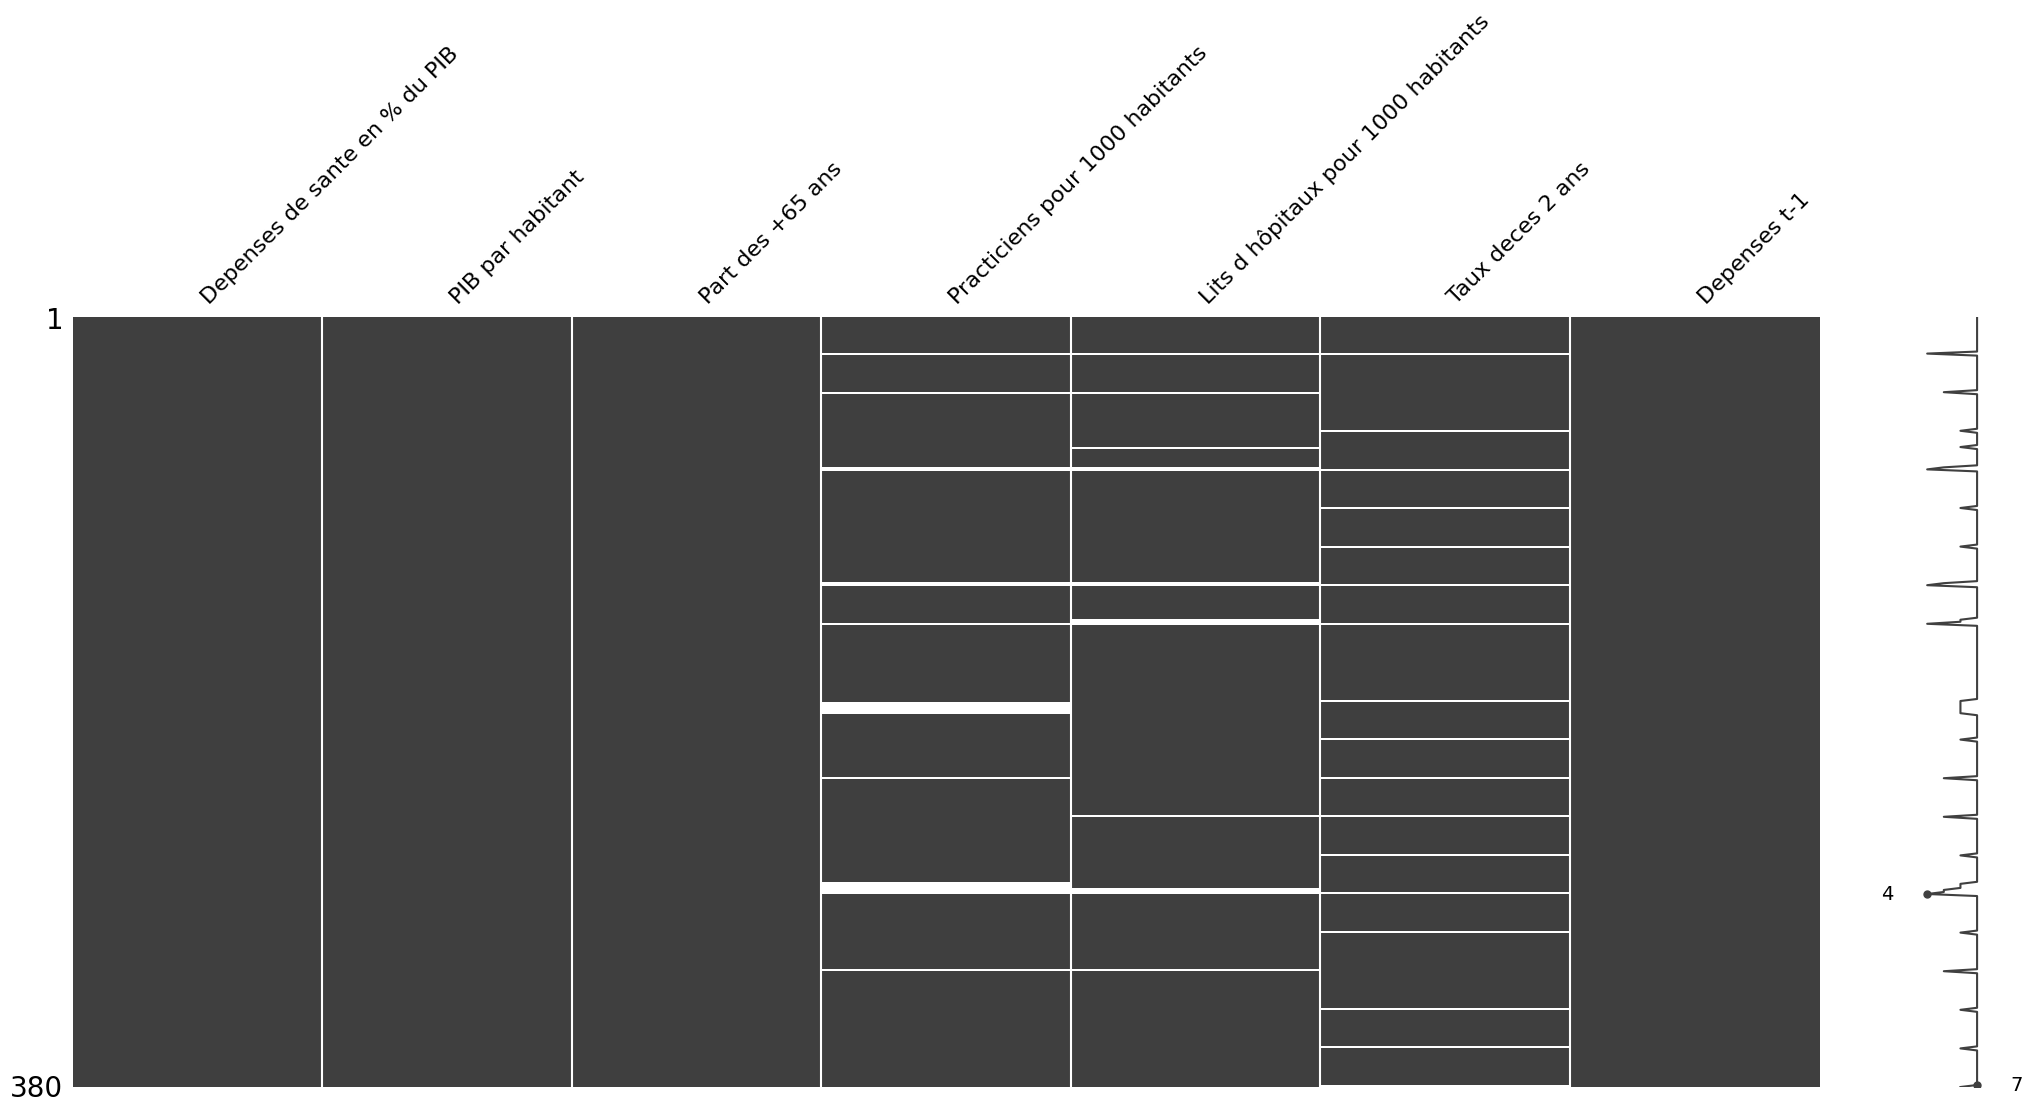

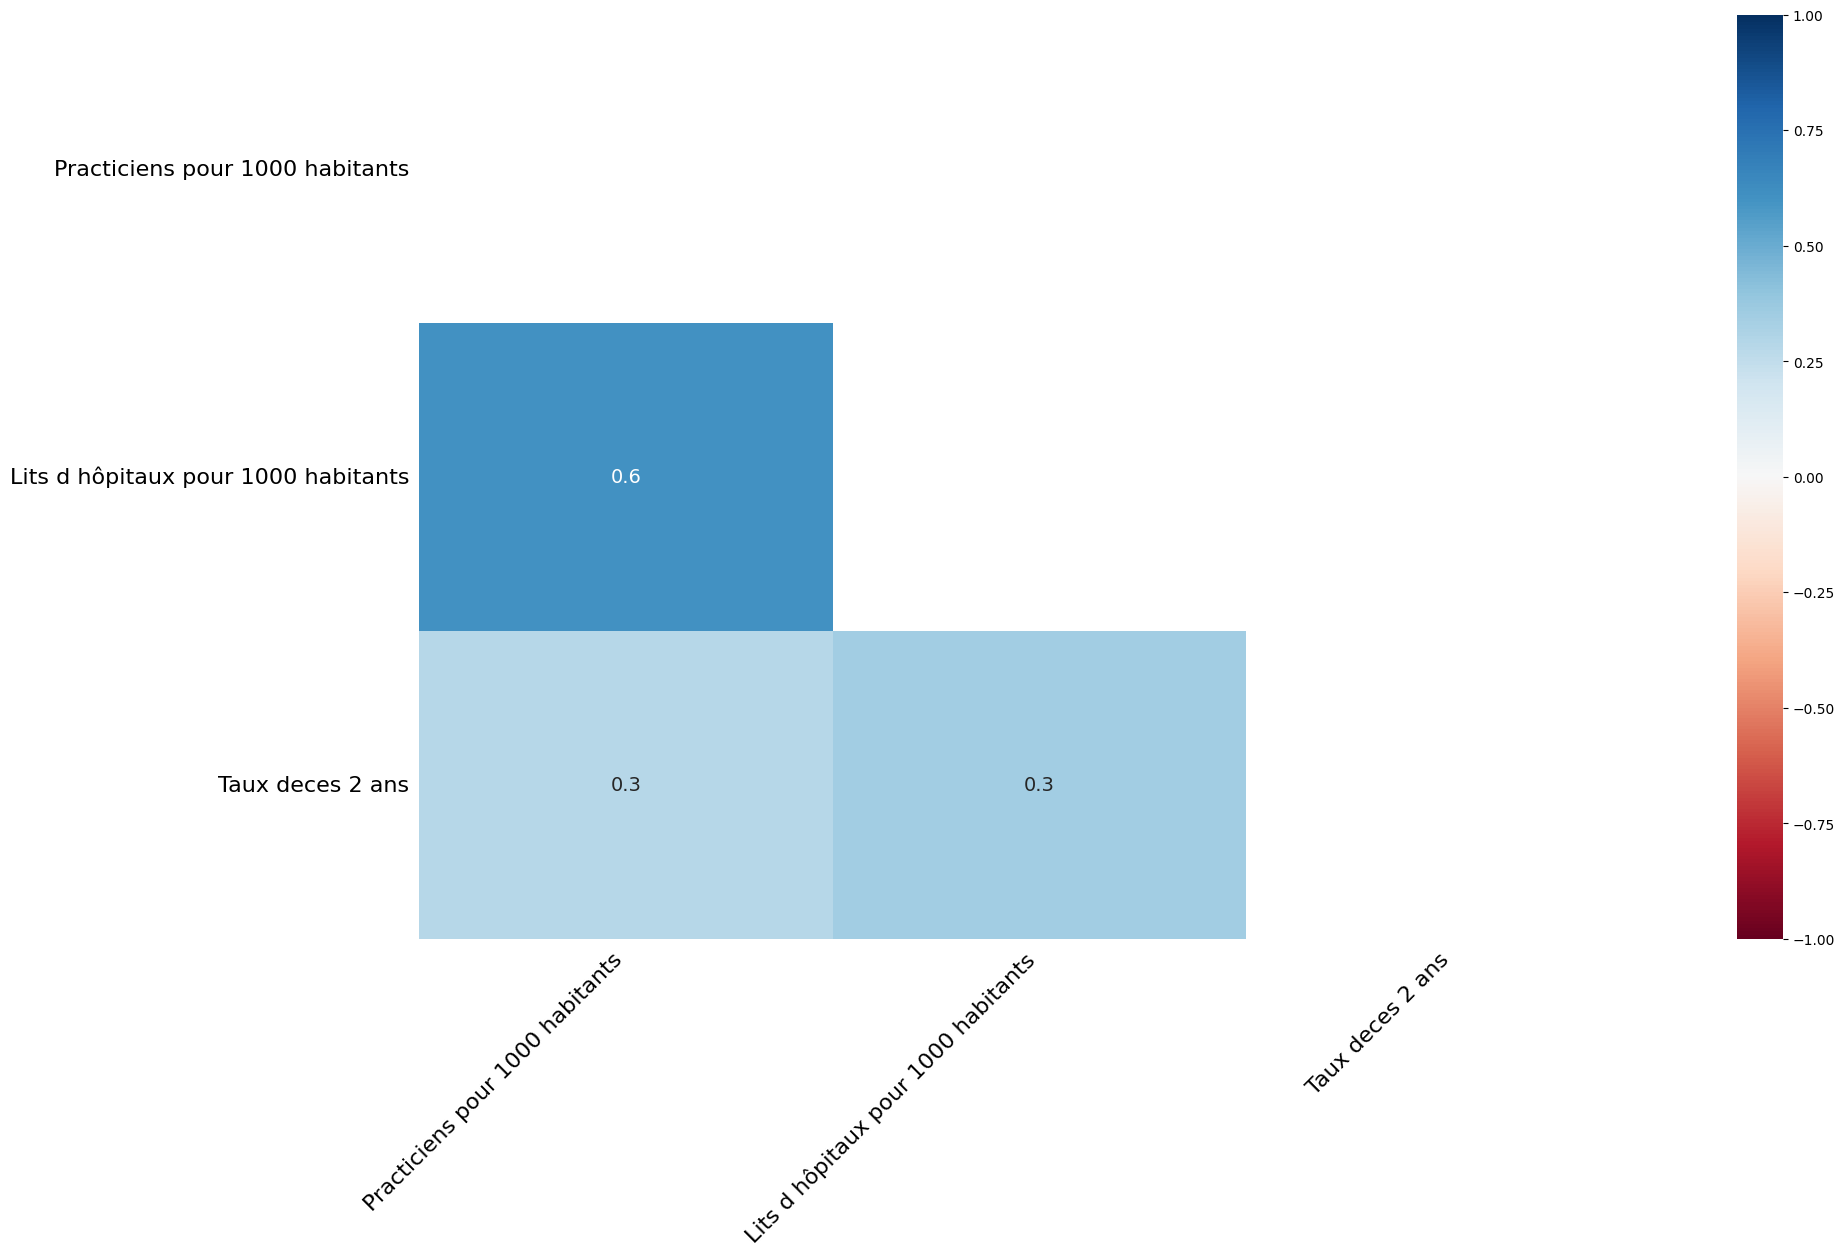

In [13]:
#visualisation des valeurs manquantes

df = panel.copy()
msno.bar(df)
msno.matrix(df)
msno.heatmap(df)

A value near -1 means if one variable appears then the other variable is very likely to be missing.  
A value near 0 means there is no dependence between the occurrence of missing values of two variables.  
A value near 1 means if one variable appears then the other variable is very likely to be present.  

In [14]:
missing_indicator = df.isna().astype(int)
corr = missing_indicator.corr()

print(corr)

                                     Depenses de sante en % du PIB  \
Depenses de sante en % du PIB                                  NaN   
PIB par habitant                                               NaN   
Part des +65 ans                                               NaN   
Practiciens pour 1000 habitants                                NaN   
Lits d hôpitaux pour 1000 habitants                            NaN   
Taux deces 2 ans                                               NaN   
Depenses t-1                                                   NaN   

                                     PIB par habitant  Part des +65 ans  \
Depenses de sante en % du PIB                     NaN               NaN   
PIB par habitant                                  NaN               NaN   
Part des +65 ans                                  NaN               NaN   
Practiciens pour 1000 habitants                   NaN               NaN   
Lits d hôpitaux pour 1000 habitants               NaN           

In [15]:
import statsmodels.stats.missing
from statsmodels.stats.missing import test_missing_complete

test_missing_complete(df)

ModuleNotFoundError: No module named 'statsmodels.stats.missing'

In [ ]:
print(len(panel['PIB par habitant']))
panel['PIB par habitant'].isnull().sum()

380


np.int64(0)

## Données manquantes

In [ ]:
#gérer les données manquantes
panel_transformed = panel.copy()

for col in panel.columns :
    panel_transformed[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))

In [ ]:
panel_transformed

Depenses de sante en % du PIB  PIB par habitant  \
Country   Year                                                    
Allemagne 2005                         10.107             129.3   
          2006                          9.962             128.1   
          2007                          9.835             127.2   
          2008                         10.032             126.3   
          2009                         10.970             127.9   
...                                       ...               ...   
Tchéquie  2019                          7.488              68.6   
          2020                          8.970              68.8   
          2021                          9.154              70.4   
          2022                          8.471              73.8   
          2023                          8.427              76.4   

                Part des +65 ans  Practiciens pour 1000 habitants  \
Country   Year                                                      
Allemagne 2005          0.186270                             3.40   
          2006          0.192509                             3.44   
          2007          0.198011                             3.49   
          2008          0.200914                             3.54   
          2009          0.204006                             3.62   
...                          ...                              ...   
Tchéquie  2019          0.195930                             4.07   
          2020          0.199331                             4.13   
          2021          0.205037                             4.26   
          2022          0.206254                             4.32   
          2023          0.203911                             4.86   

                Lits d hôpitaux pour 1000 habitants  Taux deces 2 ans  \
Country   Year                                                          
Allemagne 2005                                 6.26             2.002   
          2006                                 6.13             2.000   
          2007                                 5.57             2.031   
          2008                                 6.10             2.066   
          2009                                 6.11             2.089   
...                                             ...               ...   
Tchéquie  2019                                 5.67             2.269   
          2020                                 5.86             2.517   
          2021                                 5.93             2.478   
          2022                                 4.92             2.216   
          2023                                 4.83             2.073   

                Depenses t-1  
Country   Year                
Allemagne 2005         9.975  
          2006        10.107  
          2007         9.962  
          2008         9.835  
          2009        10.032  
...                      ...  
Tchéquie  2019         7.372  
          2020         7.488  
          2021         8.970  
          2022         9.154  
          2023         8.471  

[380 rows x 7 columns]

# Régression TTD  
On veut vérifier si contrôler par le TTD atténue l'impact du vieillissement sur les dépenses de santé.  
On fait notre régression sur plusieurs tranches d'âge au-dessus de 65 ans. Comme TTD, on utilise l'espérance de vie résiduelle de la tranche d'âge sur laquelle on se place et on remplace

# Régression et GMM